Dynamic Pricing Model — Olist E-commerce

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyRegressor
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("All imports successful!")

All imports successful!


In [2]:
orders       = pd.read_csv('data/olist_orders_dataset.csv')
order_items  = pd.read_csv('data/olist_order_items_dataset.csv')
products     = pd.read_csv('data/olist_products_dataset.csv')
reviews      = pd.read_csv('data/olist_order_reviews_dataset.csv')
category_map = pd.read_csv('data/product_category_name_translation.csv')

print(f"Orders:      {orders.shape}")
print(f"Order items: {order_items.shape}")
print(f"Products:    {products.shape}")
print(f"Reviews:     {reviews.shape}")


Orders:      (99441, 8)
Order items: (112650, 7)
Products:    (32951, 9)
Reviews:     (99224, 7)


In [4]:
# Average review score per order
avg_review = reviews.groupby('order_id')['review_score'].mean().reset_index()
avg_review.columns = ['order_id', 'avg_review_score']

# Merge orders + items + reviews
df = order_items.merge(orders[['order_id', 'order_purchase_timestamp', 'order_status']], on='order_id')
df = df.merge(avg_review, on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name',
                          'product_weight_g', 'product_length_cm',
                          'product_height_cm', 'product_width_cm']], on='product_id', how='left')
df = df.merge(category_map, on='product_category_name', how='left')

print(f"Master dataframe: {df.shape}")
df.head(3)


Master dataframe: (112650, 16)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_status,avg_review_score,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,2017-09-13 08:59:02,delivered,5.0,cool_stuff,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,2017-04-26 10:53:06,delivered,4.0,pet_shop,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,2018-01-14 14:33:31,delivered,5.0,moveis_decoracao,3050.0,33.0,13.0,33.0,furniture_decor


=== Missing Values ===
avg_review_score                  942
product_category_name            1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1627
dtype: int64

=== Price Stats ===
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

=== Top 10 Categories ===
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


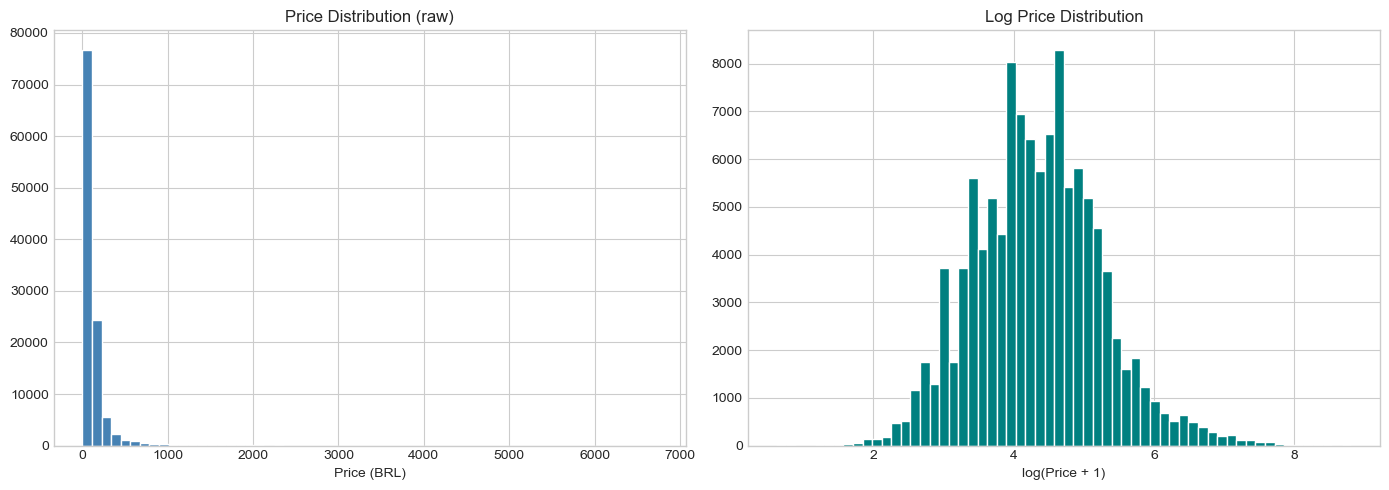

In [5]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\n=== Price Stats ===")
print(df['price'].describe())

print(f"\n=== Top 10 Categories ===")
print(df['product_category_name_english'].value_counts().head(10))

# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price (BRL)')

axes[1].hist(np.log1p(df['price']), bins=60, color='teal', edgecolor='white')
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Keep only delivered orders
df = df[df['order_status'] == 'delivered'].copy()

# Remove price outliers (keep 1st–99th percentile)
p1, p99 = df['price'].quantile(0.01), df['price'].quantile(0.99)
df = df[(df['price'] >= p1) & (df['price'] <= p99)]

# Remove freight outliers
df = df[df['freight_value'] < df['freight_value'].quantile(0.99)]

# Fill missing review scores with median
df['avg_review_score'] = df['avg_review_score'].fillna(df['avg_review_score'].median())

# Fill missing product dimensions with median
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    df[col] = df[col].fillna(df[col].median())

# Drop rows with missing category
df = df.dropna(subset=['product_category_name_english'])

# Parse timestamp
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f"Clean dataframe: {df.shape}")
print(f"Price range: {df['price'].min():.2f} – {df['price'].max():.2f} BRL")


Clean dataframe: (105468, 16)
Price range: 9.99 – 887.00 BRL


In [8]:
# Time features
df['order_month']    = df['order_purchase_timestamp'].dt.month
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['order_quarter']  = df['order_purchase_timestamp'].dt.quarter

# Product volume (proxy for size/shipping cost)
df['product_volume_cm3'] = (df['product_length_cm'] *
                             df['product_height_cm'] *
                             df['product_width_cm'])

# Freight ratio — how much of total payment is freight
df['freight_ratio'] = df['freight_value'] / (df['price'] + df['freight_value'] + 1e-6)

# Demand score per category — how many times each category sold
category_demand = df.groupby('product_category_name_english')['order_id'].count()
category_demand = category_demand / category_demand.max()  # normalize 0–1
df['category_demand_score'] = df['product_category_name_english'].map(category_demand)

# Average price per category (competitor proxy)
category_avg_price = df.groupby('product_category_name_english')['price'].mean()
df['category_avg_price'] = df['product_category_name_english'].map(category_avg_price)

# Price vs category average — how under/overpriced is this item
df['price_vs_category_avg'] = df['price'] / (df['category_avg_price'] + 1e-6)

# Seller volume — how active is the seller
seller_volume = df.groupby('seller_id')['order_id'].count()
df['seller_order_volume'] = df['seller_id'].map(seller_volume)

# Review quality score — weighted
df['review_quality'] = df['avg_review_score'] * np.log1p(df['seller_order_volume'])

print("Feature engineering done!")
print(f"Total features created: {df.shape[1]}")




Feature engineering done!
Total features created: 26


In [9]:
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['product_category_name_english'])

# Save encoder for use in Streamlit app later
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save category list for the dashboard
categories = df['product_category_name_english'].unique().tolist()
with open('categories.pkl', 'wb') as f:
    pickle.dump(sorted(categories), f)

print(f"Categories encoded: {df['category_encoded'].nunique()} unique categories")

Categories encoded: 71 unique categories


In [10]:
FEATURES = [
    'freight_value',
    'avg_review_score',
    'product_weight_g',
    'product_volume_cm3',
    'freight_ratio',
    'category_demand_score',
    'category_avg_price',
    'price_vs_category_avg',
    'seller_order_volume',
    'review_quality',
    'order_month',
    'order_dayofweek',
    'order_quarter',
    'category_encoded',
]

TARGET = 'price'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples:     {X_test.shape[0]:,}")



Training samples: 84,374
Test samples:     21,094


In [11]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)

print(f"Baseline (mean predictor)")
print(f"  RMSE: {rmse_base:.2f} BRL")
print(f"  MAE:  {mae_base:.2f} BRL")
print(f"  R²:   {r2_base:.4f}")


# ============================================================
# CELL 10 — XGBoost model
# ============================================================
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"XGBoost")
print(f"  RMSE: {rmse_xgb:.2f} BRL  (vs baseline {rmse_base:.2f})")
print(f"  MAE:  {mae_xgb:.2f} BRL")
print(f"  R²:   {r2_xgb:.4f}")



Baseline (mean predictor)
  RMSE: 110.34 BRL
  MAE:  70.63 BRL
  R²:   -0.0000
XGBoost
  RMSE: 4.11 BRL  (vs baseline 110.34)
  MAE:  1.37 BRL
  R²:   0.9986


In [12]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)]
)

y_pred_lgb = lgb_model.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb   = r2_score(y_test, y_pred_lgb)

print(f"LightGBM")
print(f"  RMSE: {rmse_lgb:.2f} BRL  (vs baseline {rmse_base:.2f})")
print(f"  MAE:  {mae_lgb:.2f} BRL")
print(f"  R²:   {r2_lgb:.4f}")



LightGBM
  RMSE: 4.01 BRL  (vs baseline 110.34)
  MAE:  1.31 BRL
  R²:   0.9987


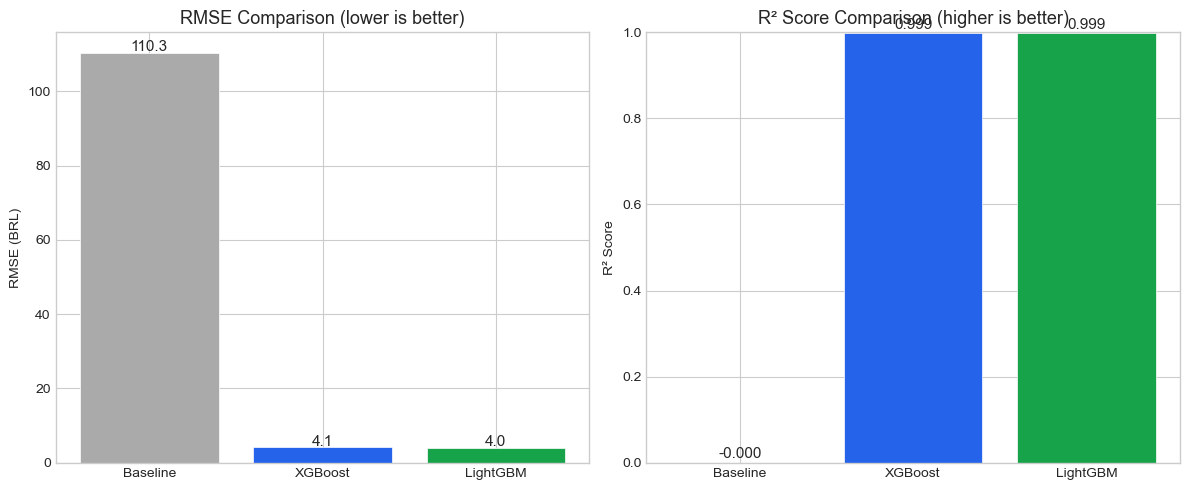

In [13]:
models = ['Baseline', 'XGBoost', 'LightGBM']
rmses  = [rmse_base, rmse_xgb, rmse_lgb]
r2s    = [r2_base, r2_xgb, r2_lgb]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#aaa', '#2563eb', '#16a34a']
axes[0].bar(models, rmses, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('RMSE Comparison (lower is better)', fontsize=13)
axes[0].set_ylabel('RMSE (BRL)')
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=11)

axes[1].bar(models, r2s, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('R² Score Comparison (higher is better)', fontsize=13)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



Best model: LightGBM
Model saved to best_model.pkl


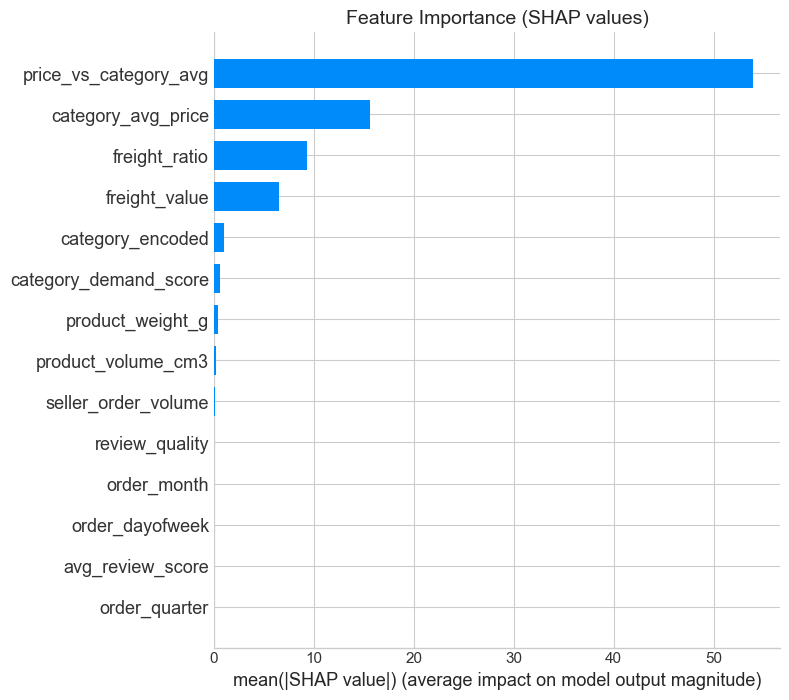

In [14]:
# Pick whichever has lower RMSE
best_model = xgb_model if rmse_xgb <= rmse_lgb else lgb_model
best_name  = "XGBoost" if rmse_xgb <= rmse_lgb else "LightGBM"
print(f"Best model: {best_name}")

import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Also save feature names for the dashboard
with open('features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("Model saved to best_model.pkl")


# ============================================================
# CELL 14 — SHAP Feature Importance
# ============================================================
# Use XGBoost for SHAP (faster)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])  # sample for speed

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURES,
                   plot_type='bar', show=False)
plt.title('Feature Importance (SHAP values)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()



=== Revenue Opportunity Analysis ===
Underpriced products (room to increase): 107 (53.5%)
  Average gap: +1.35 BRL per item
  Total revenue opportunity: +144.43 BRL

Overpriced products (risk of losing sales): 93 (46.5%)
  Average gap: -0.94 BRL per item


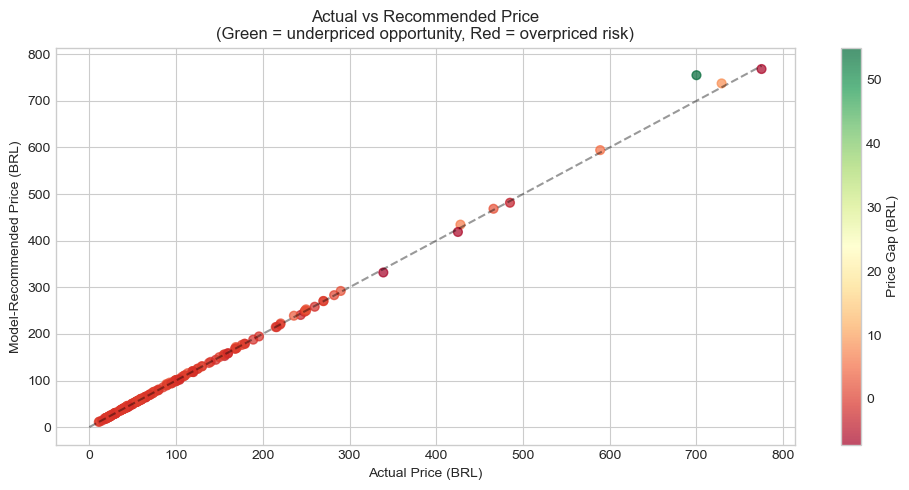


All analysis complete! Now run: streamlit run app.py


In [16]:
# Take a sample of test products and simulate revenue at different prices
sample = X_test.sample(200, random_state=42).copy()
sample['actual_price']    = y_test.loc[sample.index].values
sample['predicted_price'] = xgb_model.predict(sample[FEATURES])

# Simulate: what if we moved prices toward the model's recommendation?
sample['price_gap']          = sample['predicted_price'] - sample['actual_price']
sample['potential_revenue']  = sample['predicted_price']
sample['current_revenue']    = sample['actual_price']
sample['revenue_opportunity'] = sample['price_gap']

print("=== Revenue Opportunity Analysis ===")
underpriced = sample[sample['price_gap'] > 0]
overpriced  = sample[sample['price_gap'] < 0]

print(f"Underpriced products (room to increase): {len(underpriced)} ({len(underpriced)/len(sample)*100:.1f}%)")
print(f"  Average gap: +{underpriced['price_gap'].mean():.2f} BRL per item")
print(f"  Total revenue opportunity: +{underpriced['price_gap'].sum():.2f} BRL")

print(f"\nOverpriced products (risk of losing sales): {len(overpriced)} ({len(overpriced)/len(sample)*100:.1f}%)")
print(f"  Average gap: {overpriced['price_gap'].mean():.2f} BRL per item")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['actual_price'], sample['predicted_price'],
           c=sample['price_gap'], cmap='RdYlGn', alpha=0.7, s=40)
ax.plot([0, sample['actual_price'].max()],
        [0, sample['actual_price'].max()], 'k--', alpha=0.4, label='Perfect prediction')
ax.set_xlabel('Actual Price (BRL)')
ax.set_ylabel('Model-Recommended Price (BRL)')
ax.set_title('Actual vs Recommended Price\n(Green = underpriced opportunity, Red = overpriced risk)')
plt.colorbar(ax.collections[0], label='Price Gap (BRL)')
plt.tight_layout()
plt.savefig('revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll analysis complete! Now run: streamlit run app.py")
